<a href="https://colab.research.google.com/github/MeitingHuangChen/BI26_MEIHUA/blob/main/M3_A2_Objects_in_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


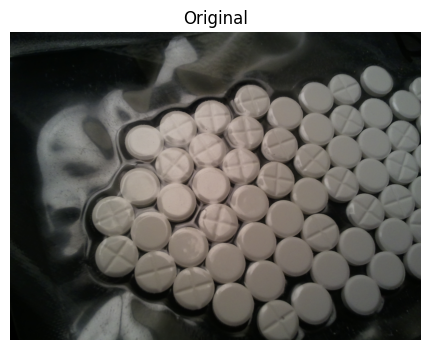

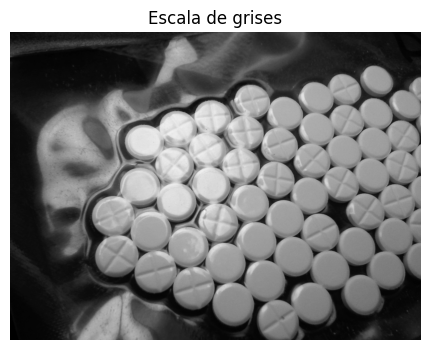

aplicando blur...
listo


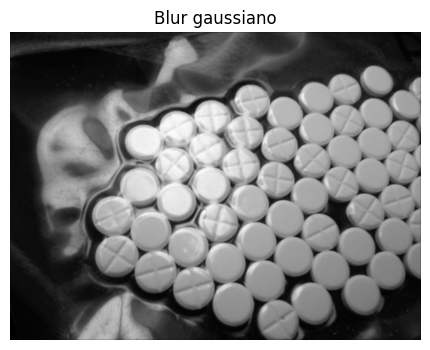

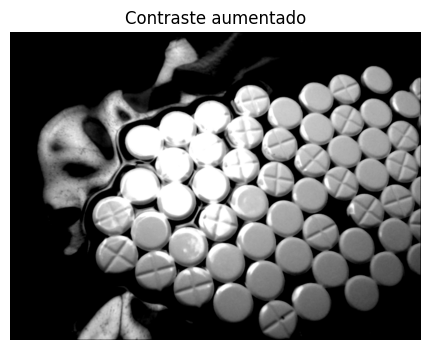

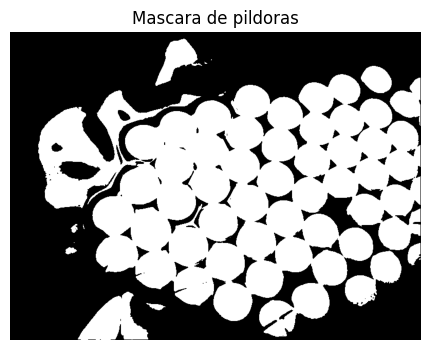

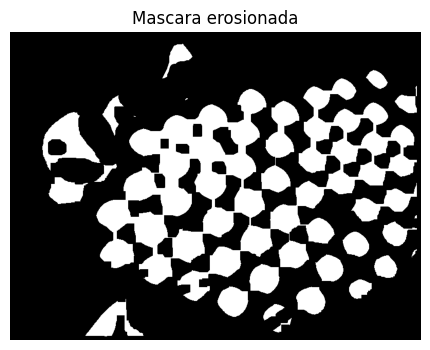

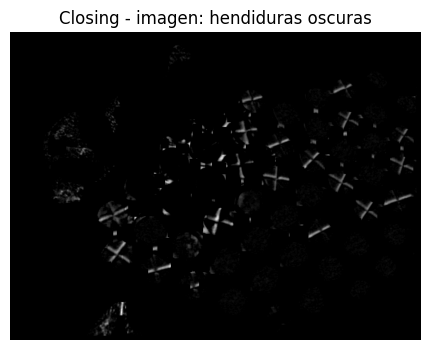

detectando lineas horizontales...


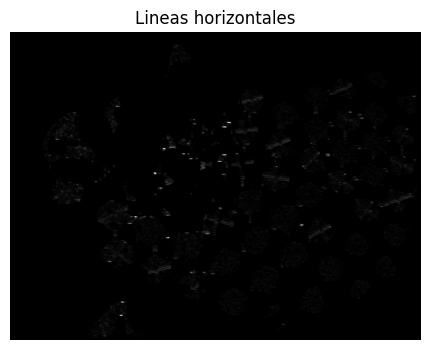

detectando lineas verticales...


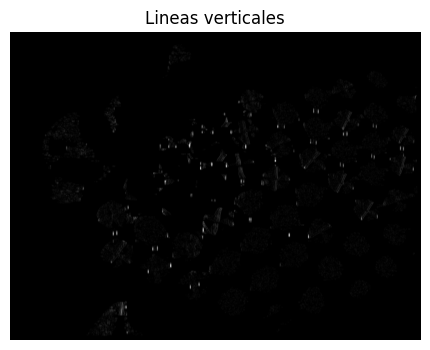

detectando lineas +45...


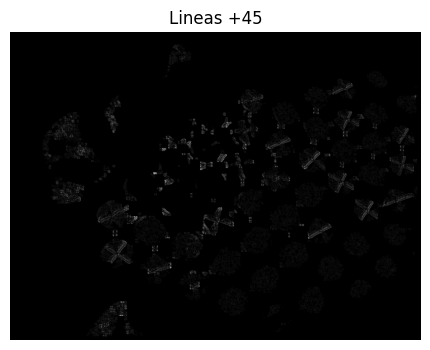

detectando lineas -45...


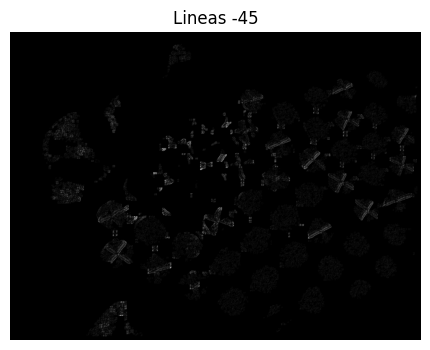

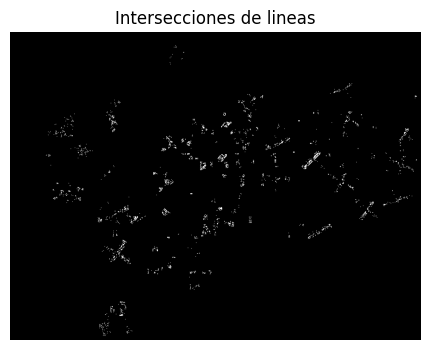

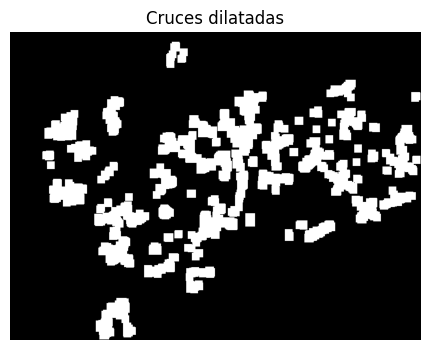

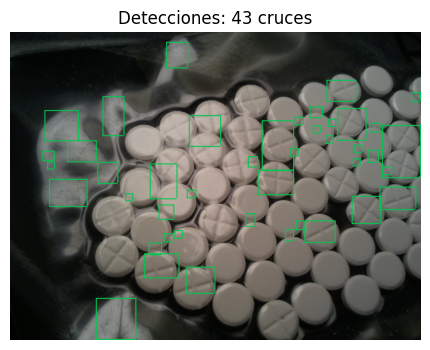

Total de pildoras con cruz detectadas: 43


In [184]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from google.colab import drive

np.random.seed(42)

# ── Cargar imagen ──────────────────────────────────────────────────────────────
drive.mount('/content/drive')
img_pil = Image.open("/content/drive/MyDrive/Colab Notebooks/pildoras.jpg").convert("RGB")
img_pil = img_pil.resize((800, 600))
img = np.array(img_pil)

plt.figure(figsize=(6, 4))
plt.title("Original")
plt.imshow(img)
plt.axis("off")
plt.show()

# ── Escala de grises ───────────────────────────────────────────────────────────
# formula estandar ITU-R BT.601 para convertir RGB a gris
# el verde tiene mas peso porque el ojo humano es mas sensible a ese canal
gris = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.title("Escala de grises")
plt.imshow(gris, cmap="gray")
plt.axis("off")
plt.show()

# ── Función de convolución ─────────────────────────────────────────────────────
# traducida directamente de filtropro.m de matlab
# recorre cada pixel y multiplica por el kernel centrado en ese pixel
# Ap es la imagen con padding de ceros para no salirse de los bordes
def convolucion(A, w):
    N, M = A.shape
    Ap = np.zeros((N + 2, M + 2))
    Ap[1:N+1, 1:M+1] = A
    B = np.zeros((N, M))
    for n_i in range(N):
        for m_i in range(M):
            for i in range(-1, 2):
                for j in range(-1, 2):
                    B[n_i, m_i] += w[i+1, j+1] * Ap[n_i - i + 1, m_i - j + 1]
    return B

# ── Blur gaussiano ─────────────────────────────────────────────────────────────
# se aplica un filtro gaussiano para reducir el ruido de la imagen
# antes de cualquier operacion morfologica
# el kernel gaussiano es el caso 2 de filtropro.m
kernel_gaussiano = np.array([[0.36, 0.6, 0.36],
                              [0.6,  1.0, 0.6 ],
                              [0.36, 0.6, 0.36]]) / 4.8976

print("aplicando blur...")
suave = convolucion(gris.astype(float), kernel_gaussiano)
suave = np.clip(suave, 0, 255).astype(np.uint8)
print("listo")

plt.figure(figsize=(6, 4))
plt.title("Blur gaussiano")
plt.imshow(suave, cmap="gray")
plt.axis("off")
plt.show()

# ── Mejora de contraste ────────────────────────────────────────────────────────
# se aumenta el contraste para resaltar las cruces que son muy sutiles
# alpha controla el contraste y beta el brillo
# la formula es: pixel_nuevo = alpha * pixel_original + beta
alpha = 3.0
beta  = -200
img_contraste = np.clip(suave.astype(float) * alpha + beta, 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.title("Contraste aumentado")
plt.imshow(img_contraste, cmap="gray")
plt.axis("off")
plt.show()

# ── Máscara de píldoras ────────────────────────────────────────────────────────
# se binariza con un umbral global para separar las pildoras del fondo oscuro
# las pildoras son claras (valor alto) y el fondo es oscuro (valor bajo)
mask_pildoras = (suave > 90).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.title("Mascara de pildoras")
plt.imshow(mask_pildoras, cmap="gray")
plt.axis("off")
plt.show()

# se aplica erosion para separar las pildoras que estan pegadas entre si
# la erosion reduce el area de cada pildora eliminando sus bordes
kernel_eros = np.ones((15, 15), dtype=bool)
mask_erosionada = ndimage.binary_erosion(mask_pildoras, structure=kernel_eros)

plt.figure(figsize=(6, 4))
plt.title("Mascara erosionada")
plt.imshow(mask_erosionada, cmap="gray")
plt.axis("off")
plt.show()

# ── Closing dentro de la máscara ──────────────────────────────────────────────
# el closing es una operacion morfologica compuesta:
# primero se dilata la imagen y luego se erosiona
# closing = dilatacion seguida de erosion
# al restar la imagen original al closing se obtienen
# las estructuras oscuras dentro de regiones claras = las cruces
# esto funciona porque las cruces son hendiduras oscuras dentro de pildoras blancas
img_dentro = img_contraste * mask_erosionada.astype(np.uint8)

kernel_closing = np.ones((11, 11), dtype=bool)

# dilatacion: expande las zonas blancas, rellena las cruces oscuras
dilatada = ndimage.grey_dilation(img_dentro, footprint=kernel_closing)

# erosion: reduce las zonas blancas de vuelta a su tamaño original
closing  = ndimage.grey_erosion(dilatada, footprint=kernel_closing)

# resta: lo que quedo son las estructuras oscuras = cruces
cruces_oscuras = np.clip(closing.astype(int) - img_dentro.astype(int), 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.title("Closing - imagen: hendiduras oscuras")
plt.imshow(cruces_oscuras, cmap="gray")
plt.axis("off")
plt.show()

# ── Detección de líneas H y V ──────────────────────────────────────────────────
# se aplican los kernels de deteccion de lineas de la presentacion del profe
# cada kernel resalta las estructuras que van en su direccion
# horizontal: detecta cambios de arriba a abajo
# vertical: detecta cambios de izquierda a derecha
# +45 y -45: detectan las diagonales de la cruz
kernel_h = np.array([[-1, -1, -1],
                     [ 2,  2,  2],
                     [-1, -1, -1]], dtype=float)

kernel_v = np.array([[-1, 2, -1],
                     [-1, 2, -1],
                     [-1, 2, -1]], dtype=float)

kernel_45 = np.array([[ 2, -1, -1],
                      [-1,  2, -1],
                      [-1, -1,  2]], dtype=float)

kernel_45n = np.array([[-1, -1,  2],
                       [-1,  2, -1],
                       [ 2, -1, -1]], dtype=float)

print("detectando lineas horizontales...")
lh = convolucion(cruces_oscuras.astype(float), kernel_h)
lh = np.clip(np.abs(lh), 0, 255).astype(np.uint8)
plt.figure(figsize=(6, 4))
plt.title("Lineas horizontales")
plt.imshow(lh, cmap="gray")
plt.axis("off")
plt.show()

print("detectando lineas verticales...")
lv = convolucion(cruces_oscuras.astype(float), kernel_v)
lv = np.clip(np.abs(lv), 0, 255).astype(np.uint8)
plt.figure(figsize=(6, 4))
plt.title("Lineas verticales")
plt.imshow(lv, cmap="gray")
plt.axis("off")
plt.show()

print("detectando lineas +45...")
l45 = convolucion(cruces_oscuras.astype(float), kernel_45)
l45 = np.clip(np.abs(l45), 0, 255).astype(np.uint8)
plt.figure(figsize=(6, 4))
plt.title("Lineas +45")
plt.imshow(l45, cmap="gray")
plt.axis("off")
plt.show()

print("detectando lineas -45...")
l45n = convolucion(cruces_oscuras.astype(float), kernel_45n)
l45n = np.clip(np.abs(l45n), 0, 255).astype(np.uint8)
plt.figure(figsize=(6, 4))
plt.title("Lineas -45")
plt.imshow(l45n, cmap="gray")
plt.axis("off")
plt.show()

# ── Intersecciones = cruces ────────────────────────────────────────────────────
# una cruz tiene lineas en todas las direcciones
# al hacer AND entre los 4 kernels solo quedan los pixeles
# donde coinciden todas las direcciones = centro de la cruz
UMBRAL_LINEA = 10
cruz = ((lh > UMBRAL_LINEA) &
        (lv > UMBRAL_LINEA) &
        (l45 > UMBRAL_LINEA) &
        (l45n > UMBRAL_LINEA)).astype(np.uint8) * 255

plt.figure(figsize=(6, 4))
plt.title("Intersecciones de lineas")
plt.imshow(cruz, cmap="gray")
plt.axis("off")
plt.show()

# ── Dilatar para unir fragmentos ──────────────────────────────────────────────
# cada cruz queda como varios fragmentos pequenos
# se dilata para unirlos en un solo blob por cruz
kernel_dil = np.ones((15, 15), dtype=bool)
cruz_dilatada = ndimage.binary_dilation(cruz > 0, structure=kernel_dil)

plt.figure(figsize=(6, 4))
plt.title("Cruces dilatadas")
plt.imshow(cruz_dilatada, cmap="gray")
plt.axis("off")
plt.show()

# ── Contar y filtrar ──────────────────────────────────────────────────────────
# se etiquetan los blobs conectados y se filtran por area y aspect ratio
# solo se cuentan los que tienen forma aproximada de cruz
# los que estan fuera de la mascara de pildoras se descartan
etiquetas, n = ndimage.label(cruz_dilatada)
detecciones = []

for i in range(1, n + 1):
    region = np.where(etiquetas == i)
    area = len(region[0])
    if 100 <= area <= 5000:
        y1, y2 = region[0].min(), region[0].max()
        x1, x2 = region[1].min(), region[1].max()
        w = x2 - x1
        h = y2 - y1
        if h > 0 and 0.3 < w / h < 3.0:
            cx = x1 + w // 2
            cy = y1 + h // 2
            # solo contar si el centro esta dentro de una pildora
            if mask_pildoras[cy, cx]:
                detecciones.append((x1, y1, w, h))

# ── Resultado final ───────────────────────────────────────────────────────────
resultado = img.copy()
for x, y, w, h in detecciones:
    resultado[y:y+2,     x:x+w] = [0, 200, 80]
    resultado[y+h:y+h+2, x:x+w] = [0, 200, 80]
    resultado[y:y+h,     x:x+2] = [0, 200, 80]
    resultado[y:y+h, x+w:x+w+2] = [0, 200, 80]

plt.figure(figsize=(6, 4))
plt.title(f"Detecciones: {len(detecciones)} cruces")
plt.imshow(resultado)
plt.axis("off")
plt.show()

print(f"Total de pildoras con cruz detectadas: {len(detecciones)}")

##**Decisión de diseño**

Pipeline final:
blur gaussiano → mejora de contraste → máscara de píldoras con umbral + erosión → closing para extraer cruces → kernels de detección de líneas H, V, +45, -45 → AND de intersecciones → dilatación → conteo con filtro de área y máscara

**Iteración 1** — blur manual con ciclos for
Lo primero fue implementar un blur manual recorriendo cada pixel con dos ciclos for, igual que en la tarea anterior. El problema fue que tardaba demasiado porque la imagen es grande. Se cambió por el kernel gaussiano de filtropro.m usando la función de convolución traducida de MATLAB, que es más eficiente y consistente con lo visto en clase.

**Iteración 2** — binarización con umbral fijo
Se intentó binarizar con un umbral fijo manual (128, 160, 180, 200). El problema fue que la imagen tiene zonas con diferente iluminación — las píldoras de arriba son más claras y las de abajo más oscuras, entonces un solo umbral no funcionaba para toda la imagen. Se probó umbral adaptativo dividiendo la imagen en bloques, pero los bloques quedaban muy bruscos con tamaño 30 y casi todo negro con tamaño 10.

**Iteración 3** — kernels de líneas directamente sobre la imagen binarizada
Se aplicaron los kernels de detección de líneas H y V de la presentación del profe directamente sobre la imagen binarizada. El problema fue que los kernels detectan cualquier cambio de intensidad, incluyendo los bordes circulares de las píldoras, generando miles de falsos positivos — llegó a detectar más de 1600 cruces cuando en la imagen no pasan de 50.

**Iteración 4**— agregar kernels +45 y -45
Se agregaron los kernels diagonales de la presentación y se hizo AND de los 4. Esto redujo los falsos positivos pero el resultado fue 0 cruces porque el AND era demasiado estricto. Se probó con solo H y V pero seguía detectando bordes.

**Iteración 5** — máscara con umbral global
Para evitar detectar fuera de las píldoras se creó una máscara binaria con umbral global de 90 sobre la imagen suavizada. Esto limpió el fondo pero las píldoras seguían pegadas y los kernels seguían detectando sus bordes internos.

**Iteración 6** — mejora de contraste
Se aumentó el contraste con alpha=3.0 y beta=-200 para resaltar las cruces que son muy sutiles. Con esto las cruces se vieron mucho más claras visualmente pero los kernels seguían detectando los bordes de las píldoras también.

**Iteración 7** — erosión para separar píldoras
Se aplicó erosión a la máscara para separar las píldoras pegadas. Se probaron kernels de 10, 15, 20 y 25. Con 25 las píldoras se separaban bien pero las cruces desaparecían. Con 10 quedaban más pegadas pero las cruces sobrevivían. Se quedó con 15 como balance.

**Iteración 8** — closing para extraer cruces
Esta fue la decisión más importante. En lugar de buscar las cruces con kernels directamente, se aplicó closing (dilatación seguida de erosión, visto en clase) y se restó la imagen original. El closing rellena las hendiduras oscuras de las cruces, y al restar la imagen original lo que queda son exactamente esas hendiduras — las cruces. Esto resolvió el problema de fondo porque ahora los kernels se aplican sobre las cruces extraídas y no sobre toda la imagen.

**Iteración 9** — kernels sobre el closing
Con las cruces ya extraídas se volvieron a aplicar los 4 kernels de líneas. El AND con umbral de 10 detectó intersecciones que corresponden a los centros de las cruces.

**Iteración 10** — dilatación y conteo
Cada cruz quedaba como varios fragmentos pequeños. Se aplicó dilatación con kernel de 15×15 para unirlos. Se filtraron los blobs por área entre 100 y 5000 píxeles y aspect ratio entre 0.3 y 3.0. Se descartaron los blobs cuyo centro no estuviera dentro de la máscara de píldoras originales.

**Iteraciones adicionales**

A lo largo del desarrollo también se intentaron otras aproximaciones que no funcionaron o se descartaron: detectar cada píldora individualmente como blob con ndimage.label para buscar cruces adentro, pero todas las píldoras salían como un solo blob gigante por estar pegadas; aplicar los kernels directo sobre la imagen con contraste sin binarizar, lo que solo detectaba bordes exteriores; hacer opening completo (erosión + dilatación) que volvía a juntar las píldoras; filtrar detecciones por circularidad; y binarización adaptativa por bloques que generaba artefactos. Además se probaron decenas de combinaciones de parámetros de forma manual y visual — umbrales, tamaños de kernel, rangos de área — ajustando en cada paso hasta encontrar valores que funcionaran razonablemente para esta imagen específica.

##**Justificación de porque no funcionó**

Desde el inicio se decidió no usar OpenCV porque no se había visto en clase y no se entendía cómo funcionaba. En cambio se optó por implementar todo manualmente usando los kernels de detección de líneas de la presentación del profe y la función de convolución traducida de MATLAB, que sí se habían visto en clase.

El resultado final detectó 43 cruces pero con varios problemas. El primero y más importante fue la variedad de iluminación de la imagen. Las píldoras de la parte superior izquierda son mucho más brillantes que las de la parte inferior derecha, lo que hace que un solo umbral global no funcione bien para toda la imagen — si el umbral es alto no detecta las cruces oscuras de las píldoras brillantes, si es bajo detecta ruido en las zonas oscuras. Esto afectó tanto la máscara de píldoras como el closing y el conteo final.

El segundo problema fue la máscara de píldoras. Al no tener una función de detección de círculos como HoughCircles de OpenCV, la máscara se construyó con un umbral global y erosión, lo que la hace imprecisa — algunas píldoras quedan parcialmente fuera de la máscara y sus cruces no se detectan, y otras zonas del fondo que son ligeramente claras entran en la máscara y generan falsos positivos.

El tercer problema fue que el closing no discrimina entre cruces y otras estructuras oscuras. Extrae cualquier hendidura oscura dentro de las píldoras, incluyendo sombras entre píldoras pegadas y pequeñas imperfecciones de la superficie, lo que genera detecciones que no corresponden a cruces reales.

El cuarto problema fue la fragmentación. Cada cruz genera múltiples fragmentos al pasar por los kernels y la dilatación para unirlos a veces une fragmentos de cruces diferentes o de bordes cercanos, resultando en múltiples detecciones por píldora en lugar de una sola.

Finalmente, las píldoras más oscuras de la esquina inferior derecha tienen cruces con contraste muy bajo incluso después de aumentar el contraste con alpha y beta. El closing no las extrae bien y simplemente no se detectan.

Creo que método funciona razonablemente bien cuando las píldoras tienen buen contraste, están separadas y la iluminación es uniforme, pero falla en los casos límite más comunes de esta imagen — píldoras pegadas, iluminación no uniforme, variación de brillo entre zonas y cruces poco profundas.